In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
df=pd.read_excel("Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
!file "Online Retail.xlsx"

Online Retail.xlsx: Microsoft Excel 2007+


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [6]:
df[df['CustomerID'].isna()]['Country'].value_counts()

,count
Country,
United Kingdom,133600
EIRE,711
Hong Kong,288
Unspecified,202
Switzerland,125
France,66
Israel,47
Portugal,39
Bahrain,2


In [7]:
df = df.dropna(subset=['CustomerID'])
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [8]:
df['Total Price']=df['Quantity']*df['UnitPrice']


/tmp/ipykernel_27270/3771993132.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total Price']=df['Quantity']*df['UnitPrice']


In [9]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [10]:
df_recency = df.groupby(by='CustomerID', as_index=False)['InvoiceDate'].max()
df_recency

,CustomerID,InvoiceDate
0,12346.0,2011-01-18 10:17:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00
...,...,...
4367,18280.0,2011-03-07 09:52:00
4368,18281.0,2011-06-12 10:53:00
4369,18282.0,2011-12-02 11:43:00
4370,18283.0,2011-12-06 12:02:00


In [11]:
reference_date = df['InvoiceDate'].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [12]:
df_recency['Recency'] = (reference_date - df_recency['InvoiceDate']).dt.days
df_recency

,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:17:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309
...,...,...,...
4367,18280.0,2011-03-07 09:52:00,277
4368,18281.0,2011-06-12 10:53:00,180
4369,18282.0,2011-12-02 11:43:00,7
4370,18283.0,2011-12-06 12:02:00,3


In [13]:
df_recency.sort_values('Recency', ascending=False)

,CustomerID,InvoiceDate,Recency
1046,13747.0,2010-12-01 10:37:00,373
359,12791.0,2010-12-01 11:27:00,373
3129,16583.0,2010-12-01 12:03:00,373
1764,14729.0,2010-12-01 12:43:00,373
4212,18074.0,2010-12-01 09:53:00,373
...,...,...,...
3723,17405.0,2011-12-08 17:12:00,0
3712,17389.0,2011-12-09 09:38:00,0
146,12526.0,2011-12-09 12:09:00,0
139,12518.0,2011-12-09 10:13:00,0


In [14]:

df_recency=df_recency[['CustomerID','Recency']].sort_values('Recency', ascending=False)
df_recency

,CustomerID,Recency
1046,13747.0,373
359,12791.0,373
3129,16583.0,373
1764,14729.0,373
4212,18074.0,373
...,...,...
3723,17405.0,0
3712,17389.0,0
146,12526.0,0
139,12518.0,0


In [15]:
df_frequency = df.groupby('CustomerID', as_index=False)['InvoiceNo'].nunique().sort_values("InvoiceNo",ascending=False)
df_frequency

,CustomerID,InvoiceNo
1895,14911.0,248
330,12748.0,224
4042,17841.0,169
1674,14606.0,128
2192,15311.0,118
...,...,...
4339,18240.0,1
27,12378.0,1
4355,18262.0,1
14,12361.0,1


In [16]:
df = df[df['Total Price'] > 0]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [17]:
df_monetary = df.groupby('CustomerID', as_index=False)['Total Price'].sum()
df_monetary

,CustomerID,Total Price
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2094.88


In [18]:
# Get the most frequent country for each customer
df_country = df.groupby('CustomerID')['Country'].agg(lambda x: x.value_counts().index[0])
df_country

,Country
CustomerID,
12346.0,United Kingdom
12347.0,Iceland
12348.0,Finland
12349.0,Italy
12350.0,Norway
...,...
18280.0,United Kingdom
18281.0,United Kingdom
18282.0,United Kingdom


In [19]:
# Ensure df_monetary has the correct column name before merging
df_monetary = df_monetary.rename(columns={'Total Price': 'Monetary'})

# Re-create rfm by merging df_recency, df_frequency, and df_monetary
rfm = pd.merge(df_recency, df_frequency, on='CustomerID')
rfm = pd.merge(rfm, df_monetary, on='CustomerID')

# Merge the country information into the RFM DataFrame
rfm = pd.merge(rfm, df_country, on='CustomerID')

# Sort by InvoiceNo (Frequency) as done in previous steps if desired
rfm = rfm.sort_values('InvoiceNo',ascending=False)
display(rfm.head())

,CustomerID,Recency,InvoiceNo,Monetary,Country
4293,14911.0,0,248,143825.06,EIRE
4238,12748.0,0,224,33719.73,United Kingdom
4165,17841.0,1,169,40991.57,United Kingdom
4314,14606.0,0,128,12156.65,United Kingdom
4083,13089.0,2,118,58825.83,United Kingdom


In [20]:
rfm = pd.merge(df_recency, df_frequency, on='CustomerID')
df_monetary = df_monetary.rename(columns={'Total Price': 'Monetary'})
rfm = pd.merge(rfm, df_monetary, on='CustomerID').sort_values('InvoiceNo',ascending=False)
rfm

,CustomerID,Recency,InvoiceNo,Monetary
4293,14911.0,0,248,143825.06
4238,12748.0,0,224,33719.73
4165,17841.0,1,169,40991.57
4314,14606.0,0,128,12156.65
4083,13089.0,2,118,58825.83
...,...,...,...,...
45,12441.0,366,1,173.55
46,16893.0,366,1,145.93
47,16125.0,366,1,289.35
48,14821.0,366,1,48.80


In [21]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['InvoiceNo'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm.sort_values('Recency',ascending=True)

,CustomerID,Recency,InvoiceNo,Monetary,R_score,F_score,M_score
4293,14911.0,0,248,143825.06,5,5,5
4302,13798.0,0,63,37153.85,5,5,5
4276,15311.0,0,118,60767.90,5,5,5
4248,13098.0,0,41,28882.44,5,5,5
4258,17949.0,0,52,58510.48,5,5,5
...,...,...,...,...,...,...,...
6,17908.0,373,1,243.28,1,1,1
5,17968.0,373,1,277.35,1,1,2
2,16583.0,373,1,233.45,1,1,1
3,14729.0,373,1,313.49,1,1,2


In [22]:
rfm['RFM_Total'] = rfm['R_score'].astype(str) + \
                  rfm['F_score'].astype(str) + \
                  rfm['M_score'].astype(str)


In [23]:
rfm

,CustomerID,Recency,InvoiceNo,Monetary,R_score,F_score,M_score,RFM_Total
4293,14911.0,0,248,143825.06,5,5,5,555
4238,12748.0,0,224,33719.73,5,5,5,555
4165,17841.0,1,169,40991.57,5,5,5,555
4314,14606.0,0,128,12156.65,5,5,5,555
4083,13089.0,2,118,58825.83,5,5,5,555
...,...,...,...,...,...,...,...,...
45,12441.0,366,1,173.55,1,2,1,121
46,16893.0,366,1,145.93,1,2,1,121
47,16125.0,366,1,289.35,1,2,2,122
48,14821.0,366,1,48.80,1,2,1,121


In [24]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])

    if r >= 4 and f >= 4:
        return 'Champion Customers'

    elif r >= 3 and f >= 3:
        return 'Loyal Customers'

    elif r >= 4 and f <= 2:
        return 'New Customers'

    elif r >= 3 and f <= 3:
        return 'Potential Loyalist customers'

    elif r <= 2 and f >= 3:
        return 'At Risk.Need Attention'

    elif r <= 2 and f <= 2:
        return 'Hibernating.Does not need attention'

    else:
        return 'Others'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [25]:
rfm

,CustomerID,Recency,InvoiceNo,Monetary,R_score,F_score,M_score,RFM_Total,Segment
4293,14911.0,0,248,143825.06,5,5,5,555,Champion Customers
4238,12748.0,0,224,33719.73,5,5,5,555,Champion Customers
4165,17841.0,1,169,40991.57,5,5,5,555,Champion Customers
4314,14606.0,0,128,12156.65,5,5,5,555,Champion Customers
4083,13089.0,2,118,58825.83,5,5,5,555,Champion Customers
...,...,...,...,...,...,...,...,...,...
45,12441.0,366,1,173.55,1,2,1,121,Hibernating.Does not need attention
46,16893.0,366,1,145.93,1,2,1,121,Hibernating.Does not need attention
47,16125.0,366,1,289.35,1,2,2,122,Hibernating.Does not need attention
48,14821.0,366,1,48.80,1,2,1,121,Hibernating.Does not need attention


In [26]:
rfm[['RFM_Total', 'Segment']].sort_values(by=['RFM_Total', 'Segment'], ascending=False)

,RFM_Total,Segment
4293,555,Champion Customers
4238,555,Champion Customers
4165,555,Champion Customers
4314,555,Champion Customers
4083,555,Champion Customers
...,...,...
420,111,Hibernating.Does not need attention
422,111,Hibernating.Does not need attention
423,111,Hibernating.Does not need attention
424,111,Hibernating.Does not need attention


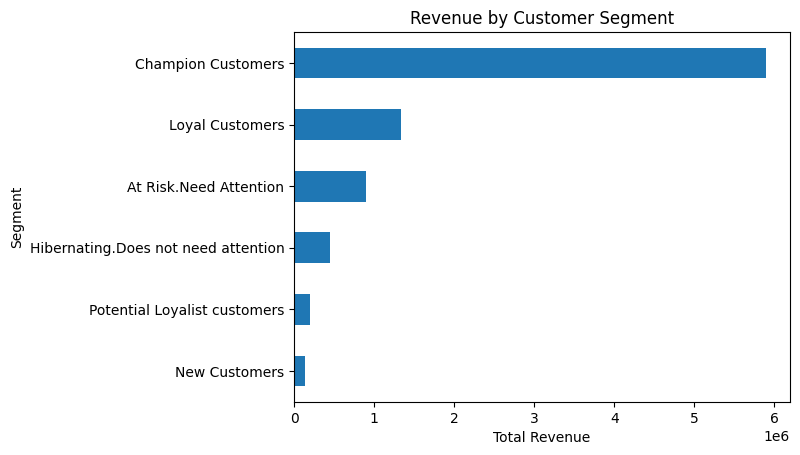

In [27]:

#This bar graph shows the total revenue vs the different customer segements

segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values()

plt.figure()
segment_revenue.plot(kind='barh')
plt.title("Revenue by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Segment")
plt.show()

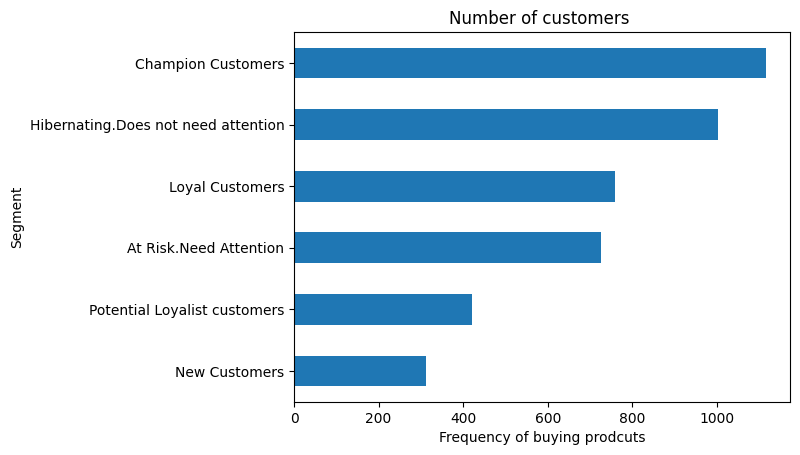

In [48]:
#This bar graph shows the number of customers in each segment vs different customer segmentations

segment_revenue = rfm.groupby('Segment')['CustomerID'].count().sort_values()

plt.figure()
segment_revenue.plot(kind='barh')
plt.title("Number of customers ")
plt.xlabel("Frequency of buying prodcuts")
plt.ylabel("Segment")
plt.show()

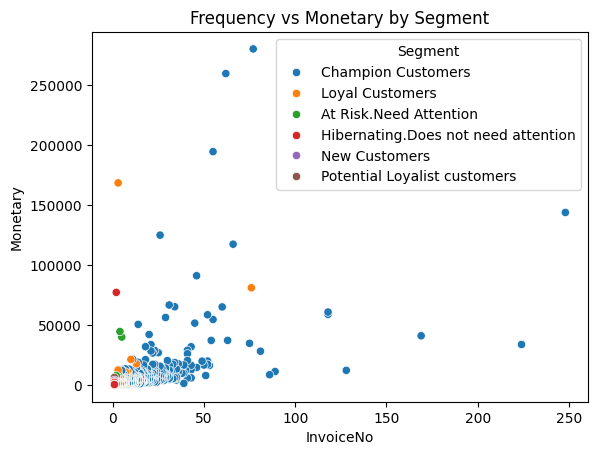

In [30]:
#Scatterplot showing the relation between the number of times a customer from different segments bought goods vs the money they spent

import seaborn as sns
plt.figure()
sns.scatterplot(data=rfm, x='InvoiceNo', y='Monetary', hue='Segment')
plt.title("Frequency vs Monetary by Segment")
plt.show()

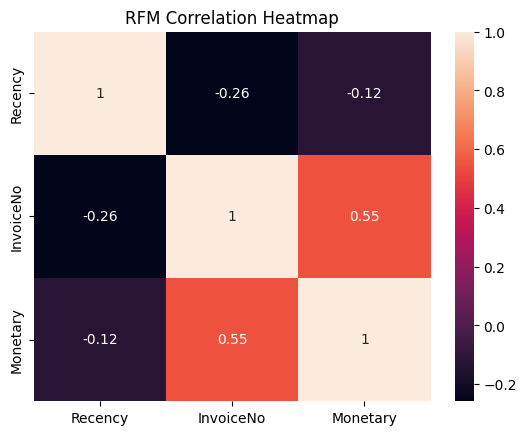

In [31]:
#heatmap showing the correalation between the total money , recency and the frequency with which customer bought goods
plt.figure()
sns.heatmap(rfm[['Recency','InvoiceNo','Monetary']].corr(), annot=True)
plt.title("RFM Correlation Heatmap")
plt.show()

In [33]:
rfm.count()

,0
CustomerID,4338
Recency,4338
InvoiceNo,4338
Monetary,4338
R_score,4338
F_score,4338
M_score,4338
RFM_Total,4338
Segment,4338


In [34]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()

revenue_percent = segment_revenue / segment_revenue.sum() * 100
print(revenue_percent.sort_values(ascending=False))


Segment
Champion Customers                     66.203106
Loyal Customers                        15.017079
At Risk.Need Attention                 10.030418
Hibernating.Does not need attention     5.034699
Potential Loyalist customers            2.234154
New Customers                           1.480543
Name: Monetary, dtype: float64


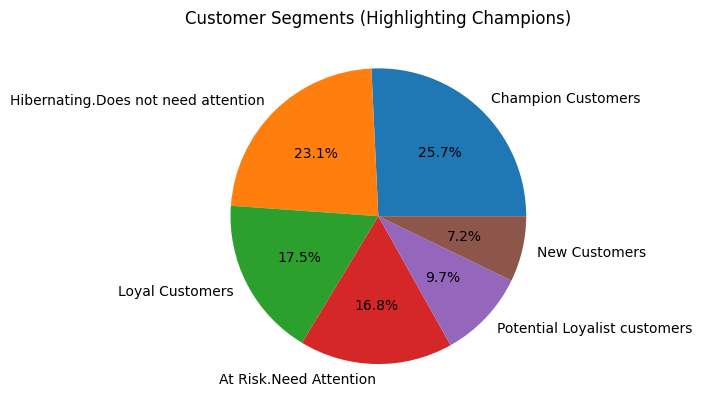

In [36]:
#pie graph showing the percentage of customer in each segment

segment_counts = rfm['Segment'].value_counts()
plt.figure()

plt.pie(segment_counts,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        explode=[0.1 if x=='Champions' else 0 for x in segment_counts.index])

plt.title("Customer Segments (Highlighting Champions)")
plt.show()

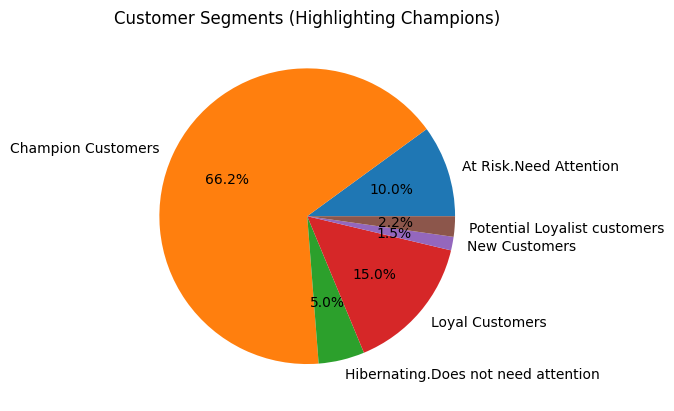

In [40]:
#pie graph shwoing the distribution of money spent by different monetary group
segment_counts = rfm.groupby('Segment')['Monetary'].sum()
plt.figure()

plt.pie(segment_counts,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        )

plt.title("Customer Segments (Highlighting Champions)")
plt.show()

In [41]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

,Monetary
Segment,
Champion Customers,5899628.810
Loyal Customers,1338233.201
At Risk.Need Attention,893851.492
Hibernating.Does not need attention,448662.591
Potential Loyalist customers,199094.620
New Customers,131937.190


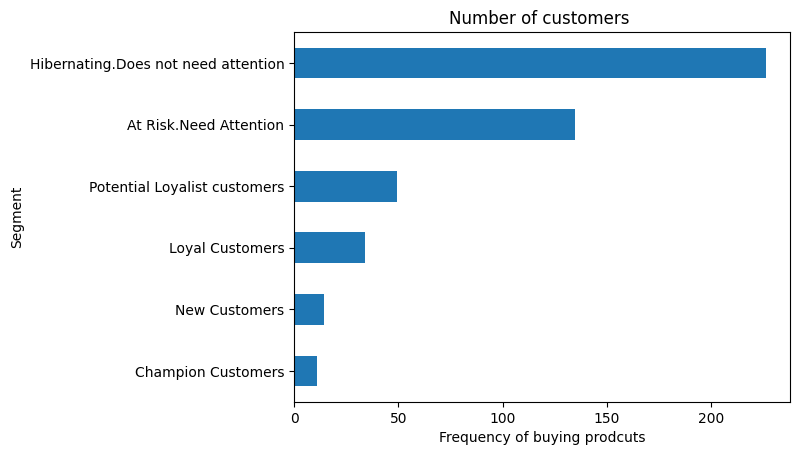

In [67]:
segment_revenue = rfm.groupby('Segment')['Recency'].mean().sort_values()

plt.figure()
segment_revenue.plot(kind='barh')
plt.title("Number of customers ")
plt.xlabel("Average Recency of buying prodcuts")
plt.ylabel("Segment")
plt.show()

In [61]:
segment_recency_mean = rfm.groupby('Segment')['Recency'].mean().sort_values(ascending=False)
segment_recency_mean

,Recency
Segment,
Hibernating.Does not need attention,226.348953
At Risk.Need Attention,134.826685
Potential Loyalist customers,49.334917
Loyal Customers,34.208169
New Customers,14.379421
Champion Customers,10.997314
